## 单隐层神经网络

In [3]:
import numpy as np #导入NumPy数学工具箱
import pandas as pd #导入Pandas数据处理工具箱
df_bank = pd.read_csv("./BankCustomer.csv") # 读取文件
df_bank.head() # 显示文件前5行

,Name,Gender,Age,City,Tenure,ProductsNo,HasCard,ActiveMember,Credit,AccountBal,Salary,Exited
0,Kan Jian,Female,40,Beijing,9,2,0,1,516,6360.66,0.0000,0
1,Xue Baochai,Male,69,Beijing,6,2,0,1,682,28605.00,0.0000,0
2,Mao Xi,Female,32,Beijing,9,1,1,1,803,10378.09,236311.0932,1
3,Zheng Nengliang,Female,37,Tianjin,0,2,1,1,778,25564.01,129909.8079,1
4,Zhi Fen,Male,55,Tianjin,4,3,1,0,547,3235.61,136976.1948,1


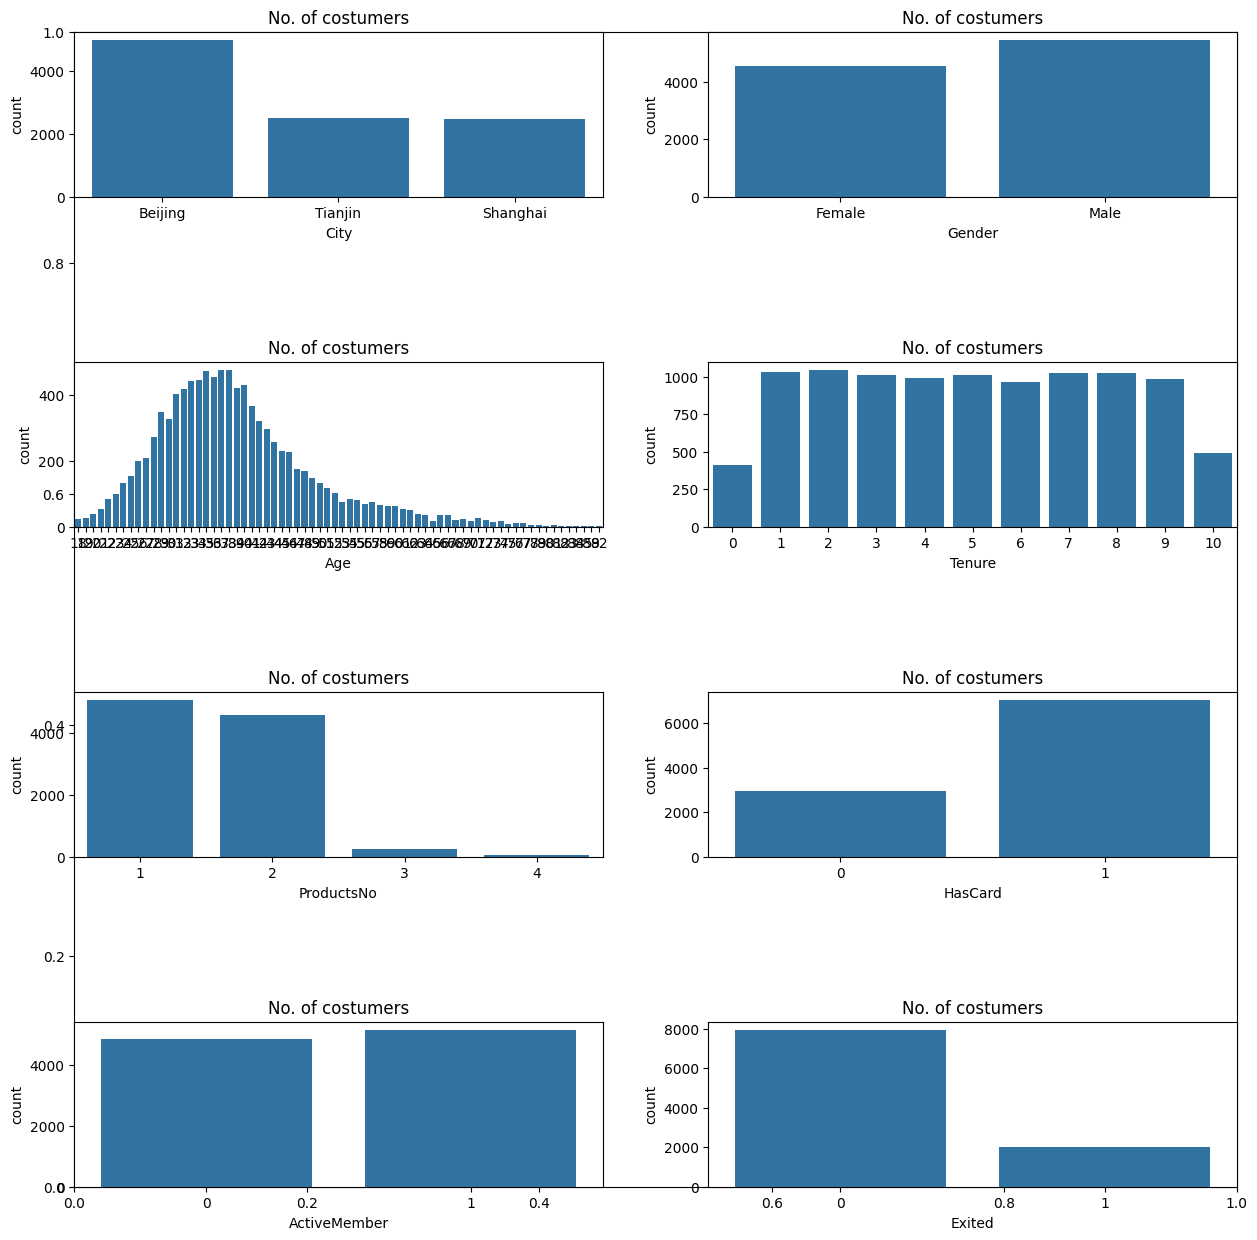

In [4]:
import matplotlib.pyplot as plt #导入matplotlib画图工具箱
import seaborn as sns #导入seaborn画图工具箱
# 显示不同特征的分布情况
features=[ 'City', 'Gender','Age','Tenure',
           'ProductsNo', 'HasCard', 'ActiveMember', 'Exited']
fig=plt.subplots(figsize=(15,15))
for i, j in enumerate(features):
    plt.subplot(4, 2, i+1)
    plt.subplots_adjust(hspace = 1.0)
    sns.countplot(x=j,data = df_bank)
    plt.title("No. of costumers")

In [5]:
# 把二元类别文本数字化
df_bank['Gender'].replace("Female",0,inplace = True)
df_bank['Gender'].replace("Male",1,inplace=True)
# 显示数字类别
print("Gender unique values",df_bank['Gender'].unique())
# 把多元类别转换成多个二元哑变量，然后贴回原始数据集
d_city = pd.get_dummies(df_bank['City'], prefix = "City")
df_bank = [df_bank, d_city]
df_bank = pd.concat(df_bank, axis = 1)
# 构建特征和标签集合
y = df_bank ['Exited']
X = df_bank.drop(['Name', 'Exited','City'], axis=1)
X.head() #显示新的特征集

Gender unique values [0 1]


/tmp/ipykernel_789/1704239601.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_bank['Gender'].replace("Female",0,inplace = True)
/tmp/ipykernel_789/1704239601.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

,Gender,Age,Tenure,ProductsNo,HasCard,ActiveMember,Credit,AccountBal,Salary,City_Beijing,City_Shanghai,City_Tianjin
0,0,40,9,2,0,1,516,6360.66,0.0000,True,False,False
1,1,69,6,2,0,1,682,28605.00,0.0000,True,False,False
2,0,32,9,1,1,1,803,10378.09,236311.0932,True,False,False
3,0,37,0,2,1,1,778,25564.01,129909.8079,False,False,True
4,1,55,4,3,1,0,547,3235.61,136976.1948,False,False,True


In [6]:
from sklearn.model_selection import train_test_split #拆分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                   test_size=0.2, random_state=0)

In [7]:
from sklearn.linear_model import LogisticRegression # 导入Sklearn模型
lr = LogisticRegression() # 逻辑回归模型
history = lr.fit(X_train,y_train) # 训练机器
print("逻辑回归测试集准确率 {:.2f}%".format(lr.score(X_test,y_test)*100))

逻辑回归测试集准确率 78.30%


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
import keras # 导入Keras库
from keras.models import Sequential # 导入Keras序贯模型
from keras.layers import Dense # 导入Keras密集连接层
ann = Sequential() # 创建一个序贯ANN(Artifical Neural Network)模型
ann.add(Dense(units=12, input_dim=12, activation = 'relu')) # 添加输入层
ann.add(Dense(units=24, activation = 'relu')) # 添加隐层
ann.add(Dense(units=1, activation = 'sigmoid')) # 添加输出层
ann.summary() # 显示网络模型(这个语句不是必须的)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 493 (1.93 KB)

 Trainable params: 493 (1.93 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from IPython.display import SVG
from keras.utils.vis_utils import model_to_dot
SVG(model_to_dot(ann,show_shapes = True ).create(prog='dot', format='svg'))

ModuleNotFoundError: No module named 'keras.utils.vis_utils'

In [10]:
# 编译神经网络，指定优化器，损失函数，以及评估标准
ann.compile(optimizer = 'adam',           #优化器
            loss = 'binary_crossentropy', #损失函数
            metrics = ['acc'])       #评估指标

In [11]:
history = ann.fit(X_train, y_train, # 指定训练集
                  epochs=30,        # 指定训练的轮次
                  batch_size=128,    # 指定数据批量
                  validation_data=(X_test, y_test)) #指定验证集,这里为了简化模型，直接用测试集数据进行验证

Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.7092 - loss: 240.9549 - val_acc: 0.5975 - val_loss: 54.9158
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6190 - loss: 36.1319 - val_acc: 0.6785 - val_loss: 24.9473
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.6420 - loss: 24.2958 - val_acc: 0.3030 - val_loss: 59.3731
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6789 - loss: 53.4964 - val_acc: 0.7725 - val_loss: 19.7223
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6865 - loss: 42.1692 - val_acc: 0.7905 - val_loss: 39.5980
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6799 - loss: 58.1055 - val_acc: 0.7870 - val_loss: 33.2778
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6933 - loss: 34.9371 - val_acc: 0.7525 - val_loss: 19.3358
Epoch 8/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.6804 - loss: 21.9051 - val_acc: 0.7755 - val_loss: 38.3399
Epoch 9/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc

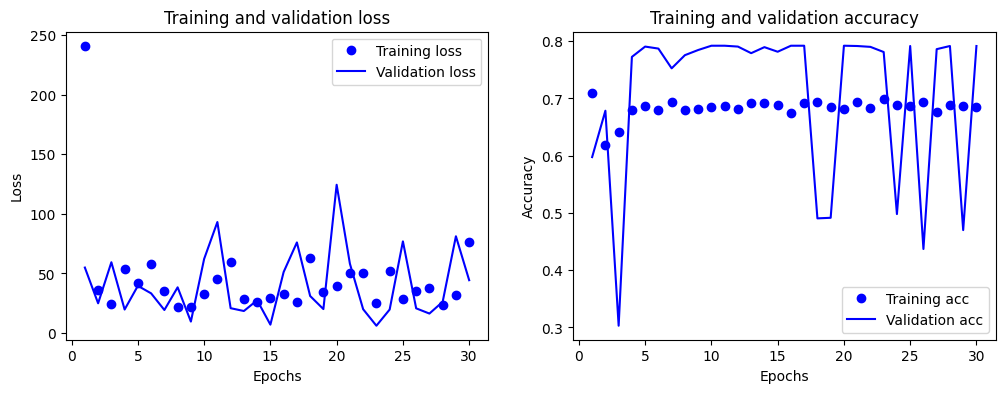

In [12]:
# 这段代码参考《Python深度学习》一书中的学习曲线的实现
def show_history(history): # 显示训练过程中的学习曲线
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.figure(figsize=(12,4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()
show_history(history) # 调用这个函数，并将神经网络训练历史数据作为参数输入

In [16]:
from sklearn.metrics import classification_report # 导入分类报告
y_pred = ann.predict(X_test, batch_size=10) # 预测测试集的标签
y_pred = np.round(y_pred) # 四舍五入, 将分类概率值转换成0/1整数值
y_test = y_test.values # 把Pandas series转换成Num Py array
y_test = y_test.reshape((len(y_test), 1)) # 转换成与y_pred相同的形状
print(classification_report(y_test, y_pred, labels=[0, 1])) #调用分类报告

200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.79      1.00      0.88      1583
           1       0.50      0.01      0.01       417

    accuracy                           0.79      2000
   macro avg       0.65      0.50      0.45      2000
weighted avg       0.73      0.79      0.70      2000



In [14]:
from sklearn.metrics import classification_report # 导入分类报告
def show_report(X_test, y_test, y_pred): # 定义一个函数显示分类报告
    if y_test.shape != (2000,1):
        y_test = y_test.values # 把Panda series转换成Numpy array
        y_test = y_test.reshape((len(y_test),1)) # 转换成与y_pred相同的形状
    print(classification_report(y_test,y_pred,labels=[0, 1])) #调用分类报告

In [15]:
from sklearn.metrics import confusion_matrix # 导入混淆矩阵
def show_matrix(y_test, y_pred): # 定义一个函数显示混淆矩阵
    cm = confusion_matrix(y_test,y_pred) # 调用混淆矩阵
    plt.title("ANN Confusion Matrix") # 标题
    sns.heatmap(cm,annot=True,cmap="Blues",fmt="d",cbar=False) # 热力图设定
    plt.show() # 显示混淆矩阵

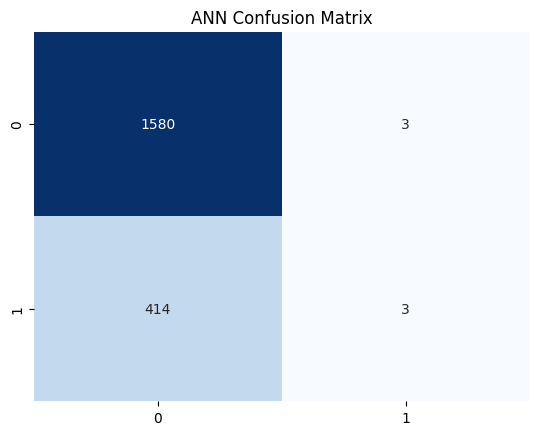

In [17]:
show_matrix(y_test, y_pred)

In [18]:
from sklearn.preprocessing import StandardScaler # 导入特征缩放器
sc = StandardScaler() # 特征缩放器
X_train = sc.fit_transform(X_train) # 拟合并应用于训练集
X_test = sc.transform (X_test) # 训练集结果应用于测试集

In [19]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression() # 逻辑回归模型
history = lr.fit(X_train,y_train) # 训练机器
print("逻辑回归测试集准确率 {:.2f}%".format(lr.score(X_test,y_test)*100))

逻辑回归测试集准确率 80.50%


In [20]:
history = ann.fit(X_train, y_train, # 指定训练集
                  epochs=30,        # 指定训练的轮次
                  batch_size=64,    # 指定数据批量
                  validation_data=(X_test, y_test)) #指定验证集
y_pred = ann.predict(X_test,batch_size=10) # 预测测试集的标签
y_pred = np.round(y_pred) # 将分类概率值转换成0/1整数值

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8014 - loss: 0.4899 - val_acc: 0.8170 - val_loss: 0.4409
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8195 - loss: 0.4253 - val_acc: 0.8210 - val_loss: 0.4282
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8223 - loss: 0.4165 - val_acc: 0.8240 - val_loss: 0.4240
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8250 - loss: 0.4125 - val_acc: 0.8260 - val_loss: 0.4205
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8257 - loss: 0.4094 - val_acc: 0.8240 - val_loss: 0.4178
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8285 - loss: 0.4071 - val_acc: 0.8305 - val_loss: 0.4156
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8295 - loss: 0.4046 - val_acc: 0.8300 - val_loss: 0.4138
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8303 - loss: 0.4025 - val_acc: 0.8325 - val_loss: 0.4117
Epoch 9/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - ac

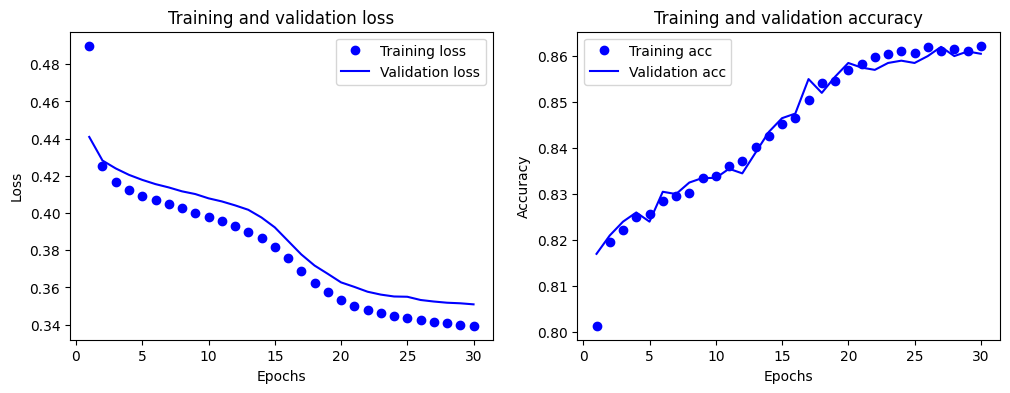

In [21]:
show_history(history)

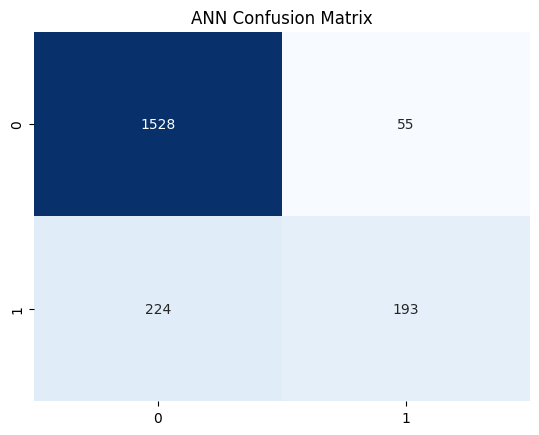

In [22]:
show_matrix(y_test, y_pred)

## 深度神经网络


In [23]:
ann = Sequential() # 创建一个序贯ANN模型
ann.add(Dense(units=12, input_dim=12, activation = 'relu')) # 添加输入层
ann.add(Dense(units=24, activation = 'relu')) # 添加隐层
ann.add(Dense(units=48, activation = 'relu')) # 添加隐层
ann.add(Dense(units=96, activation = 'relu')) # 添加隐层
ann.add(Dense(units=192, activation = 'relu')) # 添加隐层
ann.add(Dense(units=1, activation = 'sigmoid')) # 添加输出层
# 编译神经网络，指定优化器，损失函数，以及评估指标
ann.compile(optimizer = 'RMSprop', # 优化器
            loss = 'binary_crossentropy', # 损失函数
            metrics = ['acc']) # 评估指标
history = ann.fit(X_train, y_train, # 指定训练集
                  epochs=30,        # 指定训练的轮次
                  batch_size=64,    # 指定数据批量
                  validation_data=(X_test, y_test)) # 指定验证集
y_pred = ann.predict(X_test,batch_size=10) # 预测测试集的标签
y_pred = np.round(y_pred) # 将分类概率值转换成0/1整数值

Epoch 1/30


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.7977 - loss: 0.4691 - val_acc: 0.8080 - val_loss: 0.4562
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8105 - loss: 0.4368 - val_acc: 0.8140 - val_loss: 0.4336
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8154 - loss: 0.4251 - val_acc: 0.8160 - val_loss: 0.4237
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.8184 - loss: 0.4145 - val_acc: 0.8230 - val_loss: 0.4138
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8290 - loss: 0.3999 - val_acc: 0.8300 - val_loss: 0.4034
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8411 - loss: 0.3824 - val_acc: 0.8470 - val_loss: 0.3940
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8479 - loss: 0.3693 - val_acc: 0.8470 - val_loss: 0.3696
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8489 - loss: 0.3608 - val_acc: 0.8470 - val_loss: 0.3681
Epoch 9/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8497 -

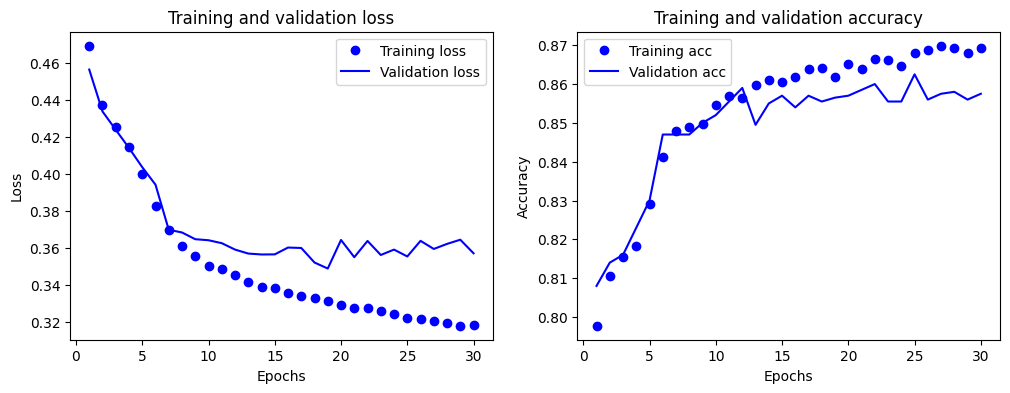

In [24]:
show_history(history)

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1583
           1       0.77      0.45      0.57       417

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.84      2000



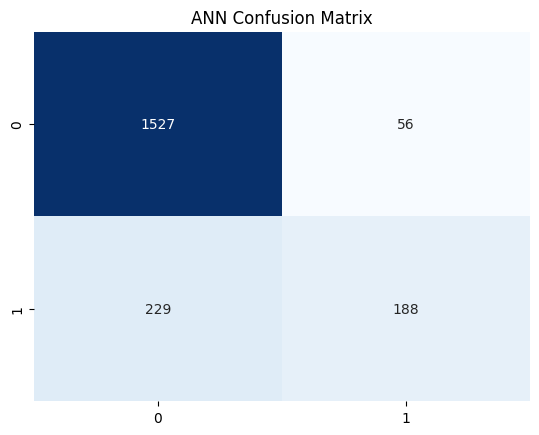

In [25]:
show_report(X_test, y_test, y_pred)
show_matrix(y_test, y_pred)

### 尝试不同的优化器

In [26]:
ann = Sequential() # 创建一个序贯ANN模型
ann.add(Dense(units=12, input_dim=12, activation = 'relu')) # 添加输入层
ann.add(Dense(units=24, activation = 'relu')) # 添加隐层
ann.add(Dense(units=48, activation = 'relu')) # 添加隐层
ann.add(Dense(units=96, activation = 'relu')) # 添加隐层
ann.add(Dense(units=192, activation = 'relu')) # 添加隐层
ann.add(Dense(units=1, activation = 'sigmoid')) # 添加输出层
# 编译神经网络，指定优化器，损失函数，以及评估标准
ann.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['acc'])
history = ann.fit(X_train, y_train, epochs=30, batch_size=64, validation_data=(X_test, y_test))
y_pred = ann.predict(X_test,batch_size=10) # 预测测试集的标签
y_pred = np.round(y_pred) # 将分类概率值转换成0/1整数值

Epoch 1/30


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - acc: 0.8020 - loss: 0.4800 - val_acc: 0.8075 - val_loss: 0.4442
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8206 - loss: 0.4216 - val_acc: 0.8270 - val_loss: 0.4063
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.8341 - loss: 0.3947 - val_acc: 0.8450 - val_loss: 0.3939
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8471 - loss: 0.3707 - val_acc: 0.8415 - val_loss: 0.3790
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8564 - loss: 0.3531 - val_acc: 0.8495 - val_loss: 0.3655
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8565 - loss: 0.3471 - val_acc: 0.8495 - val_loss: 0.3610
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8625 - loss: 0.3377 - val_acc: 0.8530 - val_loss: 0.3642
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8637 - loss: 0.3340 - val_acc: 0.8610 - val_loss: 0.3592
Epoch 9/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8648 -

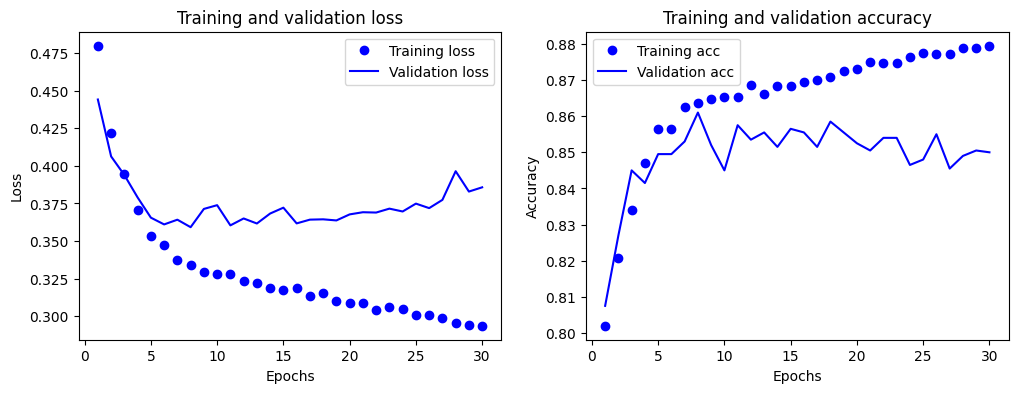

In [27]:
show_history(history)

              precision    recall  f1-score   support

           0       0.86      0.97      0.91      1583
           1       0.76      0.41      0.53       417

    accuracy                           0.85      2000
   macro avg       0.81      0.69      0.72      2000
weighted avg       0.84      0.85      0.83      2000



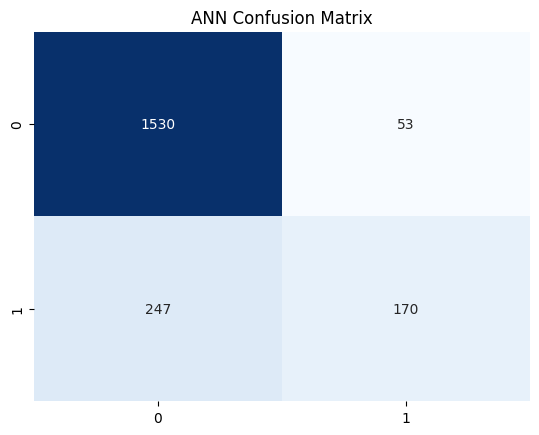

In [28]:
show_report(X_test, y_test, y_pred)
show_matrix(y_test, y_pred)

In [29]:
from keras.layers import Dropout # 导入Dropout
ann = Sequential() # 创建一个序贯ANN模型
ann.add(Dense(units=12, input_dim=12, activation = 'relu')) # 添加输入层
ann.add(Dense(units=24, activation = 'relu')) # 添加隐层
ann.add(Dropout(0.5)) # 添加Dropout
ann.add(Dense(units=48, activation = 'relu')) # 添加隐层
ann.add(Dropout(0.5)) # 添加Dropout
ann.add(Dense(units=96, activation = 'relu')) # 添加隐层
ann.add(Dropout(0.5)) # 添加Dropout
ann.add(Dense(units=192, activation = 'relu')) # 添加隐层
ann.add(Dropout(0.5)) # 添加Dropout
ann.add(Dense(units=1, activation = 'sigmoid')) # 添加输出层
ann.compile(optimizer = 'adam', # 优化器
              loss = 'binary_crossentropy', #损失函数
              metrics = ['acc']) # 评估指标
history = ann.fit(X_train, y_train, epochs=30, batch_size=64, validation_data=(X_test, y_test))
y_pred = ann.predict(X_test,batch_size=10) # 预测测试集的标签
y_pred = np.round(y_pred) # 将分类概率值转换成0/1整数值

Epoch 1/30


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - acc: 0.7884 - loss: 0.5243 - val_acc: 0.7915 - val_loss: 0.5210
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.7975 - loss: 0.4914 - val_acc: 0.7915 - val_loss: 0.4965
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7975 - loss: 0.4739 - val_acc: 0.7915 - val_loss: 0.4921
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7975 - loss: 0.4665 - val_acc: 0.7915 - val_loss: 0.4808
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7975 - loss: 0.4560 - val_acc: 0.7915 - val_loss: 0.4824
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7975 - loss: 0.4410 - val_acc: 0.7915 - val_loss: 0.4690
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7976 - loss: 0.4460 - val_acc: 0.7915 - val_loss: 0.4963
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.7983 - loss: 0.4407 - val_acc: 0.7915 - val_loss: 0.4719
Epoch 9/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8027 -

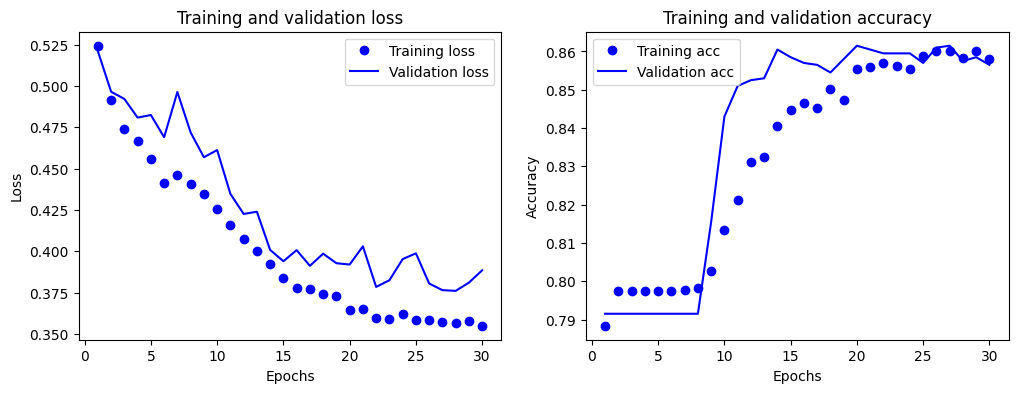

In [30]:
show_history(history)

              precision    recall  f1-score   support

           0       0.87      0.97      0.91      1583
           1       0.77      0.44      0.56       417

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000



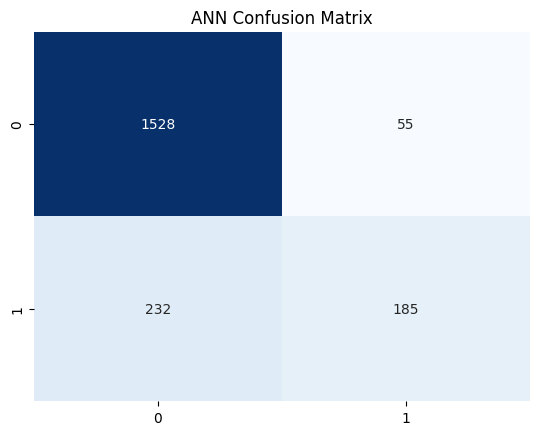

In [31]:
show_report(X_test, y_test, y_pred)
show_matrix(y_test, y_pred)